In [2]:
import hashlib
import json
import math
import sys
import os

import requests

from qwen_vl_utils import process_vision_info

# ========== 1. GPU配置（必须在任何CUDA操作之前执行）==========
cuda_num = 6  # 指定使用的GPU编号（0-7）
print(f"Use CUDA: {cuda_num}")
os.environ["CUDA_VISIBLE_DEVICES"] = f"{cuda_num}"  # 设置可见GPU设备
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"  # 允许PyTorch动态扩展显存段
from decord import VideoReader, cpu
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import cv2
from PIL import Image
from peft import PeftModel
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="tqdm")
def download_video(url, dest_path):
    response = requests.get(url, stream=True)
    with open(dest_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8096):
            f.write(chunk)
    print(f"Video downloaded to {dest_path}")


def get_video_frames(video_path, num_frames=128, cache_dir='.cache'):
    os.makedirs(cache_dir, exist_ok=True)

    video_hash = hashlib.md5(video_path.encode('utf-8')).hexdigest()
    if video_path.startswith('http://') or video_path.startswith('https://'):
        video_file_path = os.path.join(cache_dir, f'{video_hash}.mp4')
        if not os.path.exists(video_file_path):
            download_video(video_path, video_file_path)
    else:
        video_file_path = video_path

    frames_cache_file = os.path.join(cache_dir, f'{video_hash}_{num_frames}_frames.npy')
    timestamps_cache_file = os.path.join(cache_dir, f'{video_hash}_{num_frames}_timestamps.npy')

    if os.path.exists(frames_cache_file) and os.path.exists(timestamps_cache_file):
        frames = np.load(frames_cache_file)
        timestamps = np.load(timestamps_cache_file)
        return video_file_path, frames, timestamps

    vr = VideoReader(video_file_path, ctx=cpu(0))
    total_frames = len(vr)

    indices = np.linspace(0, total_frames - 1, num=num_frames, dtype=int)
    frames = vr.get_batch(indices).asnumpy()
    timestamps = np.array([vr.get_frame_timestamp(idx) for idx in indices])

    np.save(frames_cache_file, frames)
    np.save(timestamps_cache_file, timestamps)
    
    return video_file_path, frames, timestamps

def create_image_grid(images, num_columns=8):
    pil_images = [Image.fromarray(image) for image in images]
    num_rows = math.ceil(len(images) / num_columns)

    img_width, img_height = pil_images[0].size
    grid_width = num_columns * img_width
    grid_height = num_rows * img_height
    grid_image = Image.new('RGB', (grid_width, grid_height))

    for idx, image in enumerate(pil_images):
        row_idx = idx // num_columns
        col_idx = idx % num_columns
        position = (col_idx * img_width, row_idx * img_height)
        grid_image.paste(image, position)

    return grid_image
def apply_lora(model, lora_path):
    """
    加载LoRA（Low-Rank Adaptation）权重到模型
    
    参数说明：
        model: 基础模型（已加载的AutoModel实例）
        lora_path: LoRA权重文件路径
    
    返回值：
        PeftModel: 加载了LoRA权重的模型实例
    """
    model = PeftModel.from_pretrained(model, lora_path)
    return model

Use CUDA: 6


In [9]:

import torch
font_path = 'simhei中易黑体.ttf'
font_prop = fm.FontProperties(fname=font_path)

def setup_chinese_font(font_path='simhei中易黑体.ttf'):
    """设置中文字体"""
    try:
        font_prop = fm.FontProperties(fname=font_path)
        return font_prop
    except:
        print(f"警告: 无法加载字体 {font_path}，使用默认字体")
        return None
def calc_attention_concentration(att_map):
    """
    计算注意力集中度的5个核心指标
    输入: att_map - 形状为 [H, W] 或 [T, H, W] 的注意力图
    返回: dict 包含5个指标
    """
    # 如果是3D (T,H,W)，取时间平均
    if att_map.ndim == 3:
        att_map = np.mean(att_map, axis=0)
    
    # 展平并归一化
    flat = att_map.flatten()
    flat = flat / (flat.sum() + 1e-10)
    
    # 1. 空间熵 (越小越集中)
    non_zero = flat[flat > 0]
    entropy = -np.sum(non_zero * np.log(non_zero))
    
    # 2. 基尼系数 (越接近1越集中)
    sorted_vals = np.sort(flat)
    n = len(sorted_vals)
    cumsum = np.cumsum(sorted_vals)
    gini = (n + 1 - 2 * np.sum(cumsum) / cumsum[-1]) / n
    
    # 3. 有效面积比 (越小越集中)
    sorted_desc = sorted_vals[::-1]
    cumsum_desc = np.cumsum(sorted_desc)
    idx_90 = np.argmax(cumsum_desc >= 0.9)
    area_ratio = (idx_90 + 1) / n
    
    # 4. 峰值均值比 (越大越集中)
    peak_mean = att_map.max() / (att_map.mean() + 1e-10)
    
    # 5. 方差 (越大越集中)
    variance = np.var(att_map)
    
    return {
        'entropy': entropy,
        'gini': gini,
        'area_ratio': area_ratio,
        'peak_mean': peak_mean,
        'variance': variance
    }


# ==================== 注意力热力图可视化 ====================
def overlay_heatmaps_triple(images, heatmaps, check_words, alpha=0.6, save_path=None):
    """
    可视化注意力热力图：纵向排列
    第一行：所有原始图片
    第二行：所有热力图
    第三行：所有叠加图
    
    Args:
        images: 原始图像数组 (N, H, W, C)
        heatmaps: 注意力热力图数组 (N, H_att, W_att)
        check_words: 当前检查的关键词（用于标题）
        alpha: 热力图透明度（0-1之间）
        save_path: 保存路径（可选）
    """
    N = len(images)  # 图像数量
    
    # 创建子图：3行（原图、热力图、叠加图），N列（每个样本一列）
    fig, axes = plt.subplots(3, N, figsize=(2 * N, 2 * 3))
    
    # 如果只有一张图，确保axes是二维数组
    if N == 1:
        axes = axes.reshape(3, -1)
    
    # 遍历每一帧
    for i in range(N):
        img = images[i].astype(np.uint8)
        heatmap = heatmaps[i]
        
        # ---------- 1. 将热力图缩放到图像尺寸 ----------
        heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
        
        # ---------- 2. 归一化热力图到0-255 ----------
        heatmap_min, heatmap_max = heatmap_resized.min(), heatmap_resized.max()
        if heatmap_max - heatmap_min > 1e-8:
            heatmap_norm = (heatmap_resized - heatmap_min) / (heatmap_max - heatmap_min)
        else:
            heatmap_norm = heatmap_resized - heatmap_min
        heatmap_norm = (heatmap_norm * 255).astype(np.uint8)
        
        # ---------- 3. 应用颜色映射（JET色图） ----------
        heatmap_color = cv2.applyColorMap(heatmap_norm, cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        
        # ---------- 4. 叠加热力图到原图 ----------
        overlay = cv2.addWeighted(img, 1-alpha, heatmap_color, alpha, 0)
        
        # ---------- 5. 绘制三行图像 ----------
        # 第一行：原始图片
        axes[0, i].imshow(img)
        axes[0, i].set_title(f'Frame {i+1}', fontsize=10)
        axes[0, i].axis('off')
        
        # 第二行：热力图
        axes[1, i].imshow(heatmap_color)
        axes[1, i].set_title(f'Heatmap {i+1}', fontsize=10)
        axes[1, i].axis('off')
        
        # 第三行：叠加图
        axes[2, i].imshow(overlay)
        axes[2, i].set_title(f'Overlay {i+1}', fontsize=10)
        axes[2, i].axis('off')
    
    # 添加行标签（在左侧）
    row_labels = ['Original', 'Heatmap', 'Overlay']
    for row in range(3):
        axes[row, 0].set_ylabel(row_labels[row], fontsize=12, fontweight='bold', 
                                rotation=90, labelpad=10)
    
    # 添加总标题
    plt.suptitle(f'Attention Visualization for "{check_words}"', fontsize=14, 
                 fontproperties=font_prop, y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"图片已保存到: {save_path}")
    
    # plt.show()
    # return plt

# ==================== 视频帧提取函数 ====================
def extract_frames(video_path, num_frames=None):
    """
    从视频中等间隔提取指定数量的帧
    
    Args:
        video_path: 视频文件路径
        num_frames: 需要提取的帧数
    
    Returns:
        tuple: (采样帧数组, 帧索引列表)
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"无法打开视频: {video_path}")
    
    # ---------- 1. 获取视频信息 ----------
    fps_original = cap.get(cv2.CAP_PROP_FPS)          # 原始帧率
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # 总帧数
    duration = total_frames / fps_original            # 视频时长（秒）
    
    # print(f"视频: {total_frames}帧, {fps_original:.2f}fps, 时长: {duration:.3f}秒")
    if num_frames is None:
        num_frames=total_frames
    # print(f"目标提取帧数: {num_frames}")
    
    # ---------- 2. 计算采样帧索引 ----------
    if num_frames > 1:
        frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    else:
        frame_indices = [total_frames // 2]  # 只取中间帧
    
    # print(f"采样帧索引: {frame_indices}")
    
    # ---------- 3. 提取指定帧 ----------
    sampled_frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)  # 跳转到指定帧
        ret, frame = cap.read()
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # BGR转RGB
            sampled_frames.append(frame)
    
    cap.release()
    # print(f"成功提取: {len(sampled_frames)}帧")
    
    return np.array(sampled_frames), frame_indices
def extract_attentions(gpt_msg,result,processor,save_path=None,vis=True):
    output_atts = result["outputs_dict"]["attentions"]  # 注意力权重
    response = result["response_msg"]                   # 模型预测结果
    # print(response)
    generated_ids = result["outputs_dict"].sequences    # 完整生成序列
    input_ids = result["inputs_dict"].input_ids         # 输入token序列

    # ---------- 6. 获取视觉特征的时空维度 ----------
    if hasattr(result["inputs_dict"], "image_grid_thw"):
        t, h, w = result["inputs_dict"]["image_grid_thw"][0]  # 图像：时间、高、宽
    
    if hasattr(result["inputs_dict"], "video_grid_thw"):
        t, h, w = result["inputs_dict"]["video_grid_thw"][0]  # 视频：时间、高、宽
    
    if vis: print("batch, h, w:", (t, h, w))

    # ---------- 7. 查找视觉token范围 ----------
    # 构建完整的输入token序列（包含输入部分）
    generated_ids_all = [
        out_ids[:len(in_ids)] 
        for in_ids, out_ids in zip(input_ids, generated_ids)
    ]
    
    vision_start = -1
    vision_end = -1
    
    # 遍历token，找到视觉开始和结束标记
    for idx, token in enumerate(generated_ids_all[0]):
        word = processor.tokenizer.decode([token])
        if word == "<|image_pad|>" or word == "<|video_pad|>":
            continue
        if vis: print(idx, word, end=" ")
        if word == "<|vision_start|>":
            vision_start = idx
        if word == "<|vision_end|>":
            vision_end = idx
    
    # 提取输出部分的token
    generated_ids_output = [
        out_ids[len(in_ids):] 
        for in_ids, out_ids in zip(input_ids, generated_ids)
    ]
    
    print("\n" + "="*50)
    print("输出token序列:")
    for idx, token in enumerate(generated_ids_output[0]):
        word = processor.tokenizer.decode([token])
        print(idx, word, end=" ")

    print("\n")
    # 注意力范围：视觉开始之后到视觉结束
    att_range_start = vision_start + 1
    att_range_end = vision_end
    print("注意力提取区间:",att_range_start,att_range_end)

    # ---------- 8. 提取特定词的注意力 ----------
    # word_num_start, word_num_end = 18, 23  # 取第一个输出token
    word_num_start, word_num_end = map(int, input("请输入起始和结束索引（空格分割）: ").split())
    print("输入的词索引:",word_num_start, word_num_end)
    check_words = processor.decode(generated_ids_output[0][word_num_start:word_num_end], skip_special_tokens=False)
    print("\n\n检查关键词:", check_words)

    # 提取对应token的注意力权重
    atts = output_atts[word_num_start:word_num_end]  # (num_words, num_layers, batch, heads, seq_len, ...)

    # 整理注意力数据结构
    all_words_attention = []
    for word_att in atts:
        all_lays_attention = []
        for lay_att in word_att:
            heads_attention = []
            for head_idx in range(28):  # 28个注意力头
                att_list = lay_att[0, head_idx, 0, att_range_start:att_range_end]  # 只取视觉部分
                att_map = att_list
                heads_attention.append(att_map.cpu().float())
            all_lays_attention.append(heads_attention)
        all_words_attention.append(all_lays_attention)
    
    # 转换为numpy数组: (words, layers, heads, visual_tokens, h, w)
    all_words_attention = np.array(all_words_attention)
    if vis: print("all_words_attention shape:", all_words_attention.shape)

    # ---------- 9. 聚合注意力权重 ----------
    # 跨词平均 -> (layers, heads, visual_tokens, h, w)
    word_att = np.mean(all_words_attention, axis=0)
    # 跨层平均 -> (heads, visual_tokens, h, w)
    layer_att = np.mean(word_att, axis=0)
    # 跨头平均 -> (visual_tokens, h, w)
    head_att = np.mean(layer_att, axis=0)
    
    if vis: print("word_att shape:", word_att.shape)
    if vis: print("layer_att shape:", layer_att.shape)
    if vis: print("head_att shape:", head_att.shape)
    if vis: print("视觉token数量:", len(generated_ids_all[0][att_range_start:att_range_end]))

    # ---------- 10. 重塑注意力图并可视化 ----------
    # 将注意力图重塑为 (t, h//2, w//2)
    reshape_att = head_att.reshape([t, h//2, w//2])
    print("重塑后注意力图 shape:", reshape_att.shape)
    result2 = calc_attention_concentration(reshape_att)

    # 打印结果
    print(f"空间熵: {result2['entropy']:.4f}")
    print(f"基尼系数: {result2['gini']:.4f}")
    print(f"有效面积比: {result2['area_ratio']*100:.2f}%")
    print(f"峰值均值比: {result2['peak_mean']:.2f}")
    print(f"方差: {result2['variance']:.6f}")


    # 处理图像数据
    if hasattr(result["inputs_dict"], "image_grid_thw"):
        file_path =gpt_msg["image"][0]
        img = Image.open(file_path)
        img_np = np.array([img])  # 单张图像
        frames = img_np
        if vis: print("frames.shape:", frames.shape)
        if vis: print("head_att.shape:", reshape_att.shape)
        
        # 可视化并保存
        return overlay_heatmaps_triple(
            frames, reshape_att, check_words, alpha=0.5, 
            save_path=save_path
        )
    
    # 处理视频数据
    if hasattr(result["inputs_dict"], "video_grid_thw"):
        
        video_path =gpt_msg["video"][0]
        print("正在处理视频数据...",video_path)
        frames, frame_indices = extract_frames(video_path, num_frames=t)
        if vis: print("frames.shape:", frames.shape)
        if vis: print("reshape_att.shape:", reshape_att.shape)
        
        # 可视化并保存
        return overlay_heatmaps_triple(
            frames, reshape_att, check_words, alpha=0.5, 
            save_path=save_path
        )
def inference(model,processor,video, prompt):
    """
    执行模型推理
    
    Args:
        video: 视频路径
        prompt: 输入提示
        max_new_tokens: 最大生成token数
        total_pixels: 总像素数
        min_pixels: 最小像素数
        max_frames: 最大帧数
        sample_fps: 采样帧率
    
    Returns:
        Dict: 包含推理结果、输入输出、响应和参考数据的字典
    """
    
    model.eval()  # 切换到评估模式
    
    # ---------- 1. 构建输入数据 ----------
    messages = [
            {"role": "user", "content": [
                    {"video": video,
                    "fps": 4, 
                    "min_pixels": 224 * 224,
                    "max_pixels": 224 * 224,
                    "min_frames": 16,
                    "max_frames": 64 },              # 最多8帧
                    {"type": "text", "text": prompt},
                ]
            }
        ]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs, video_kwargs = process_vision_info(messages, return_video_kwargs=True)
    
    # 处理输入：文本、图像、视频
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
        **video_kwargs
    )
    
    # 将输入移到GPU
    device = next(model.parameters()).device
    inputs = inputs.to("cuda:0")

    # ---------- 2. 配置生成参数 ----------
    generation_kwargs = {
        "do_sample": False,              # 贪婪解码（确定性输出）
        "num_beams": 1,                  # 束搜索宽度（1表示贪婪搜索）
        "max_new_tokens": 200,           # 最大生成token数（原500过长）
        "min_new_tokens": 1,             # 最少生成token数
        "repetition_penalty": 1.2,       # 重复惩罚系数（防止生成循环）
        "eos_token_id": processor.tokenizer.eos_token_id,  # 结束符token ID
        "pad_token_id": processor.tokenizer.pad_token_id,  # 填充符token ID
    }
    # generation_kwargs = {
    #     "do_sample": False,
    #     "num_beams": 1,
    #     "max_new_tokens": 500,
    # }
    # ---------- 3. 执行模型推理 ----------
    with torch.no_grad():  # 禁用梯度计算以节省内存
        outputs = model.generate(
            **inputs,
            **generation_kwargs,
            return_dict_in_generate=True,  # 返回字典格式
            output_scores=True,             # 输出分数
            output_hidden_states=False,     # 不输出隐藏状态
            output_attentions=True  # 根据需要输出注意力权重
        )
        



    generated_ids = outputs.sequences  # 生成的token序列

    # ---------- 4. 解码生成的token ----------
    # 去除输入部分，只保留新生成的token
    generated_ids_trimmed = [
        out_ids[len(in_ids):] 
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    
    # 将token序列解码为文本
    response = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)[0]
    

    # ---------- 5. 返回结果 ----------
    return {
        "success": True,
        "inputs_dict": inputs,          # 输入数据字典
        "outputs_dict": outputs,        # 输出数据字典
        "input_msg": messages,          # 原始输入消息
        "response_msg": response,       # 模型预测结果
    }


In [ ]:
from transformers import AutoProcessor, AutoModelForVision2Seq
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="transformers")
import os 

model_path = "../../weights_lora/Model/vlm_best_merged_model_PVD" #  The following output example is from a tiny test model
# model_path = "/home/mzhao/公共大模型/Qwen2.5-VL-7B-Instruct" #  The following output example is from a tiny test model

processor = AutoProcessor.from_pretrained(model_path)


model, output_loading_info = AutoModelForVision2Seq.from_pretrained(model_path, torch_dtype="auto", device_map="auto", output_loading_info=True,attn_implementation="eager")


print("output_loading_info", output_loading_info)

The tokenizer you are loading from '/home/mzhao/ECHO_VIEW/weights_lora/Model/vlm_best_merged_model_PVD' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 4/4 [00:05<00:00,  1.30s/it]

output_loading_info {'missing_keys': [], 'unexpected_keys': [], 'mismatched_keys': [], 'error_msgs': []}


64
视频路径: ../../Data/dicom_videos_group/Dataset/group_1/2024031509524300050569525e9/Doppler_Parasternal_Long.mp4
在彩色多普勒图像中可以看到左心房、肺静脉和右心室等结构，在二维图像是可见到四腔观下的心脏轮廓以及主动脉根部搏动情况；CDFI显示了血流信号分布及方向性信息。根据这些信息可以判断出存在二尖瓣反流的情况。

输出token序列:
0 在 1 彩色 2 多 3 普 4 勒 5 图像 6 中 7 可以看到 8 左 9 心 10 房 11 、 12 肺 13 静脉 14 和 15 右 16 心 17 室 18 等 19 结构 20 ，在 21 二维 22 图 23 像是 24 可见 25 到 26 四 27 腔 28 观 29 下的 30 心脏 31 轮廓 32 以及 33 主动 34 脉 35 根 36 部 37 搏 38 动 39 情况 40 ； 41 CDF 42 I 43 显示 44 了 45 血 46 流 47 信号 48 分布 49 及 50 方向 51 性 52 信息 53 。 54 根据 55 这些 56 信息 57 可以 58 判断 59 出 60 存在 61 二 62 尖 63 瓣 64 反 65 流 66 的情况 67 。 68 <|im_end|> 

注意力提取区间: 15 527
输入的词索引: 61 66


检查关键词: 二尖瓣反流
重塑后注意力图 shape: (8, 8, 8)
空间熵: 3.8324
基尼系数: 0.4484
有效面积比: 65.62%
峰值均值比: 3.71
方差: 0.000000
正在处理视频数据... ../../Data/dicom_videos_group/Dataset/group_1/2024031509524300050569525e9/Doppler_Parasternal_Long.mp4


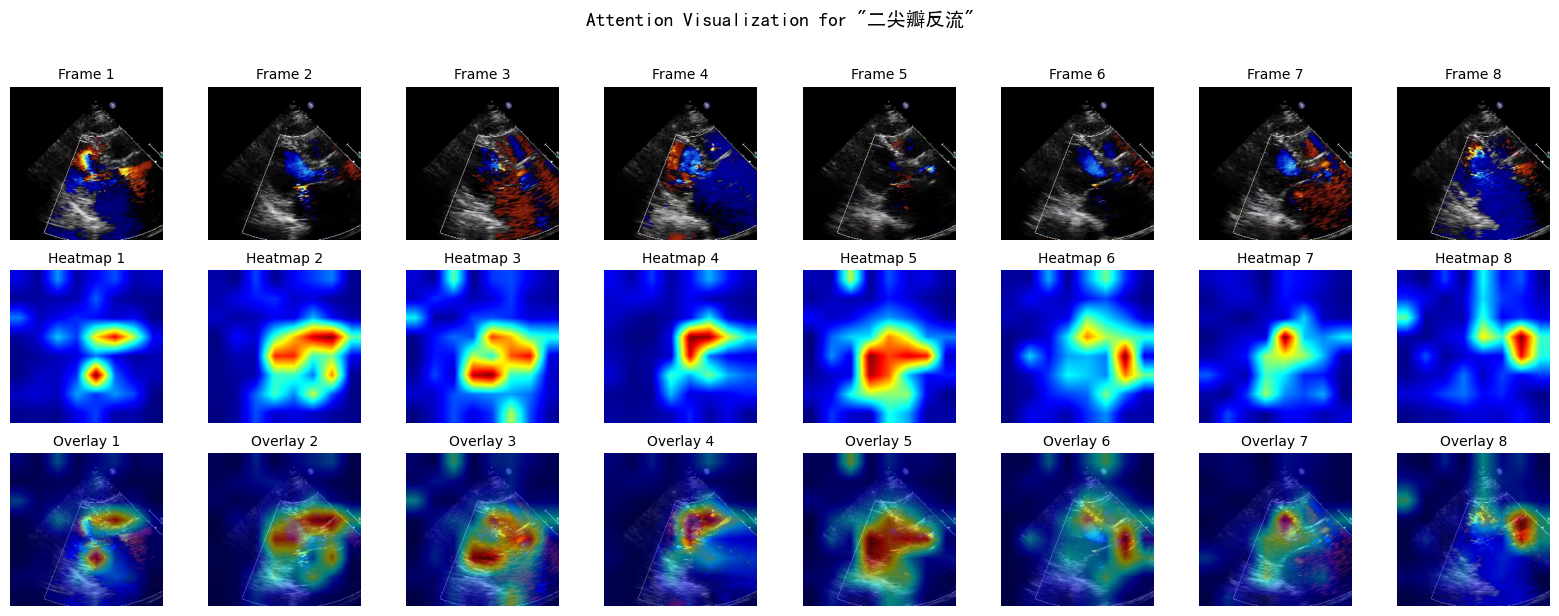

In [10]:
###  2.   有视频
msg=   {
    "id": "Dataset/group_1/2024031509524300050569525e9",
    "video": [
      "../../Data/dicom_videos_group/Dataset/group_1/2024031509524300050569525e9/Doppler_Parasternal_Long.mp4"
    ],
    "diag_item": "二尖瓣反流",
    "mark": 1,
    "conversations": [
      {
        "from": "human",
        "value": "<video>\n请分析这段心脏超声视频，请根据超声影像特征判断是否存在二尖瓣反流现象。只输出'是'或'否'"
      },
      {
        "from": "gpt",
        "value": "是"
      }
    ]
  }
msg["conversations"][0]["value"] = "<video>\n请查看这段超声视频，并仔细观察二尖瓣的位置是否有二尖瓣反流的特征，如果有，描述其严重程度。"
root=""
msg["video"][0]=os.path.join(root,msg["video"][0])
video_url = msg["video"][0]
prompt = msg["conversations"][0]["value"].replace("<video>","").strip()
video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
print(len(frames))
image_grid = create_image_grid(frames, num_columns=8)
# display(image_grid.resize((640, 640)))
# 
print("视频路径:", video_path)
model.to("cuda:0")
result = inference(model,processor,video_path, prompt)
print(result["response_msg"])
extract_attentions(msg,result,processor,save_path=None,vis=False)

64
视频路径: ../../Data/dicom_videos_group/Dataset/group_1/2024042221485800050569525e9/Doppler_Parasternal_Long.mp4
从图片中无法直接判断是否存在二尖瓣反流的情况或评估其严重程度。通常情况下，在要准确诊断是否存在二尖瓣反流及其严重程度需要通过专业的医疗设备如彩色多普勒超声进行检查。

在临床实践中：
- 如果有异常血流信号（例如湍流、射流等）出现在二尖瓣区域，则可能提示着可能存在二尖瓣反流。
- 为了更精确地确定情况并了解具体严重度，请建议咨询专业医生以获得详细的医学意见和进一步的确诊方法。

输出token序列:
0 从 1 图片 2 中 3 无法 4 直接 5 判断 6 是否存在 7 二 8 尖 9 瓣 10 反 11 流 12 的情况 13 或 14 评估 15 其 16 严重 17 程度 18 。 19 通常 20 情况下 21 ，在 22 要 23 准确 24 诊断 25 是否 26 存在 27 二 28 尖 29 瓣 30 反 31 流 32 及其 33 严重 34 程度 35 需要 36 通过 37 专业的 38 医疗 39 设备 40 如 41 彩色 42 多 43 普 44 勒 45 超 46 声 47 进行 48 检查 49 。

 50 在 51 临床 52 实践中 53 ：
 54 - 55  如果 56 有 57 异常 58 血 59 流 60 信号 61 （ 62 例如 63 湍 64 流 65 、 66 射 67 流 68 等 69 ） 70 出现在 71 二 72 尖 73 瓣 74 区域 75 ，则 76 可能 77 提示 78 着 79 可能存在 80 二 81 尖 82 瓣 83 反 84 流 85 。
 86 - 87   88 为了 89 更 90 精确 91 地 92 确定 93 情况 94 并 95 了解 96 具体 97 严重 98 度 99 ，请 100 建议 101 咨询 102 专业 103 医生 104 以 105 获得 106 详细的 107 医学 108 意见 109 和 110 进一步 111 的确 112 诊 113 方法 114 。 115 <|im_end|> 

注意力提取区间: 15 527

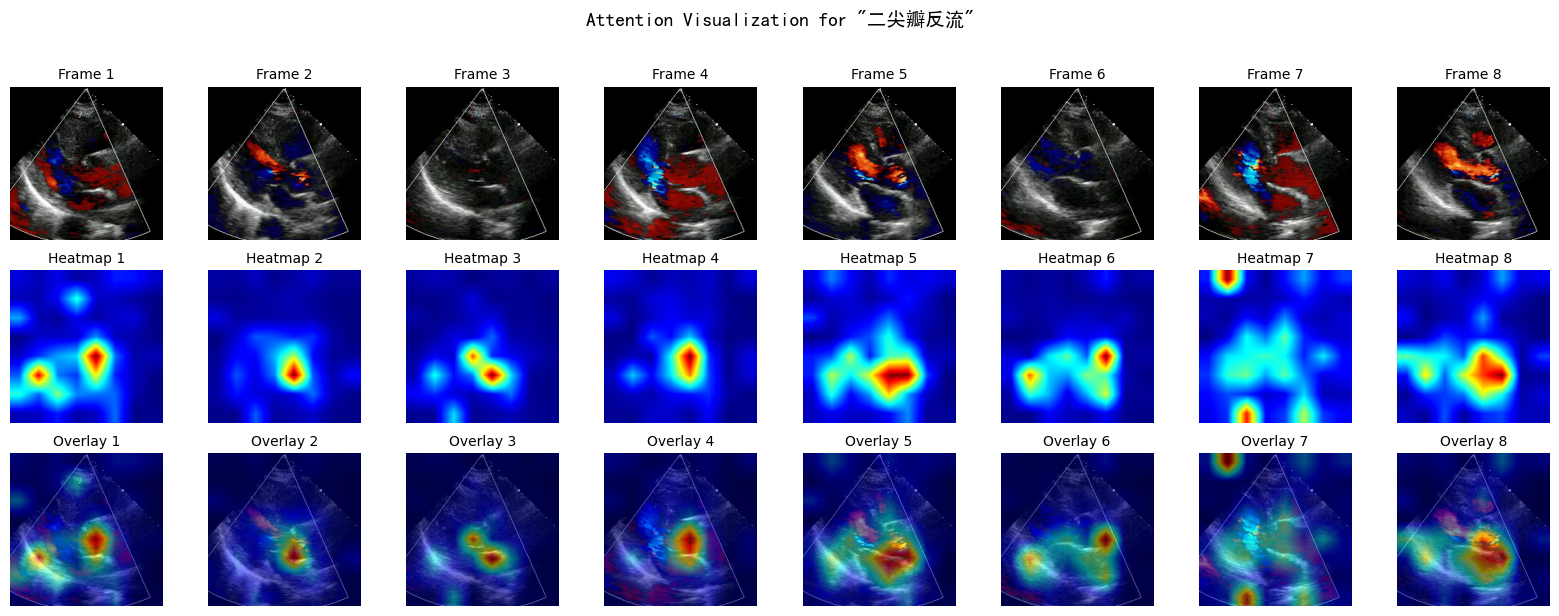

In [11]:
###  2.   有视频
msg=  {
    "id": "Dataset/group_1/2024042221485800050569525e9",
    "video": [
      "../../Data/dicom_videos_group/Dataset/group_1/2024042221485800050569525e9/Doppler_Parasternal_Long.mp4"
    ],
    "diag_item": "二尖瓣反流",
    "mark": -1,
    "conversations": [
      {
        "from": "human",
        "value": "<video>\n请分析这段心脏超声视频，请根据超声影像特征判断是否存在二尖瓣反流现象。只输出'是'或'否'"
      },
      {
        "from": "gpt",
        "value": "否"
      }
    ]
  }
msg["conversations"][0]["value"] = "<video>\n请查看这段超声视频，并仔细观察二尖瓣的位置是否有二尖瓣反流的特征，如果有，描述其严重程度。"
root=""
msg["video"][0]=os.path.join(root,msg["video"][0])
video_url = msg["video"][0]
prompt = msg["conversations"][0]["value"].replace("<video>","").strip()
video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
print(len(frames))
image_grid = create_image_grid(frames, num_columns=8)
# display(image_grid.resize((640, 640)))
# 
print("视频路径:", video_path)
model.to("cuda:0")
result = inference(model,processor,video_path, prompt)
print(result["response_msg"])
extract_attentions(msg,result,processor,save_path=None,vis=False)

64
视频路径: ../../Data/dicom_videos_group/Dataset/group_5/20240217033452000505695f0c0/Doppler_Parasternal_Long.mp4
是图中所示，在心脏切面显示了二尖瓣在收缩期时有明显的开放和关闭动作，但没有直接证据表明存在严重的二尖瓣反流现象（例如：异常增大的血流量、心室扩张或肺动脉高压等）。然而，请注意这仅基于单帧图像进行分析；为了准确评估病情需要结合整个心动周期的数据以及临床症状来做出诊断。

建议您咨询心血管专科医生以获得更详细的医学意见与检查结果解读。


输出token序列:
0 是 1 图 2 中 3 所示 4 ，在 5 心脏 6 切 7 面 8 显示 9 了 10 二 11 尖 12 瓣 13 在 14 收缩 15 期 16 时 17 有 18 明显的 19 开放 20 和 21 关闭 22 动作 23 ， 24 但 25 没有 26 直接 27 证据 28 表明 29 存在 30 严重的 31 二 32 尖 33 瓣 34 反 35 流 36 现象 37 （ 38 例如 39 ： 40 异常 41 增 42 大的 43 血 44 流量 45 、 46 心 47 室 48 扩张 49 或 50 肺 51 动脉 52 高压 53 等 54 ）。 55 然而 56 ，请 57 注意 58 这 59 仅 60 基于 61 单 62 帧 63 图像 64 进行 65 分析 66 ； 67 为了 68 准确 69 评估 70 病情 71 需要 72 结合 73 整个 74 心动 75 周期 76 的数据 77 以及 78 临床 79 症状 80 来 81 做出 82 诊断 83 。

 84 建议 85 您 86 咨询 87 心血管 88 专科 89 医生 90 以 91 获得 92 更 93 详细的 94 医学 95 意见 96 与 97 检查 98 结果 99 解读 100 。
 101 <|im_end|> 

注意力提取区间: 15 527
输入的词索引: 31 36


检查关键词: 二尖瓣反流
重塑后注意力图 shape: (8, 8, 8)
空间熵: 3.5876
基尼系数: 0.5619
有效面积比: 60.94%
峰值均值比: 5.53
方差: 0.00

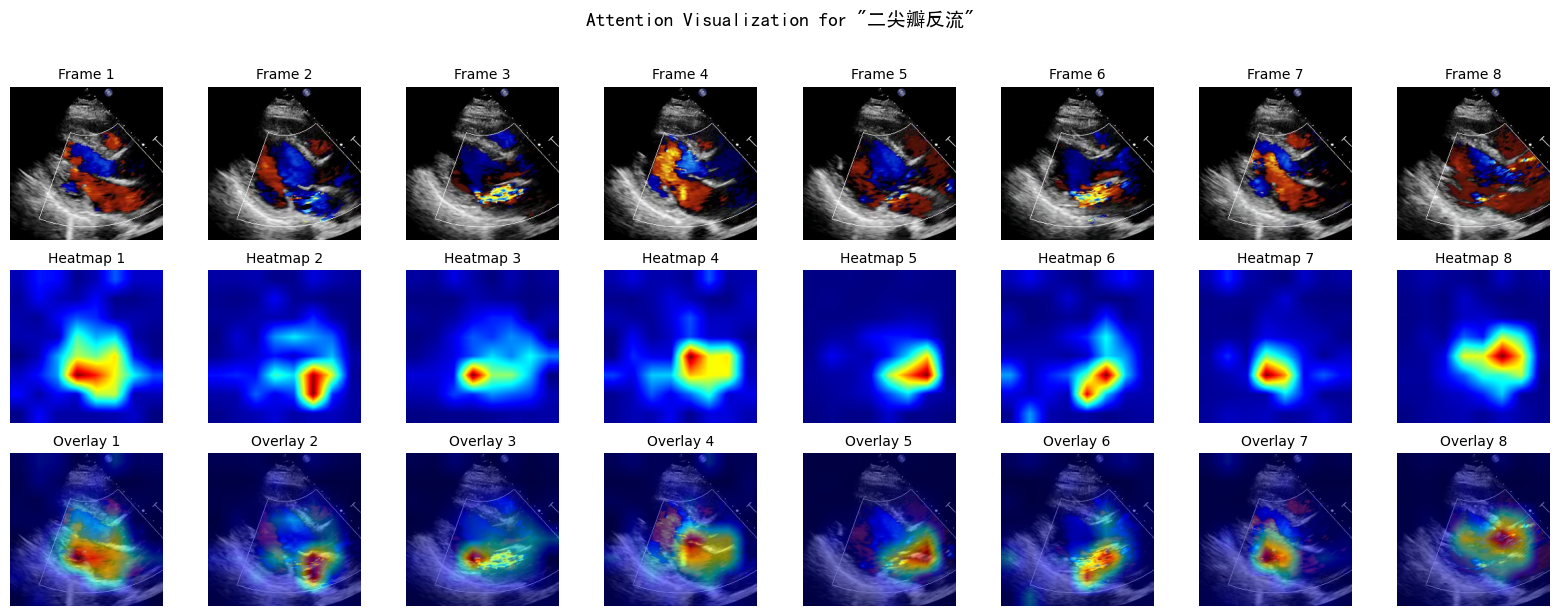

In [12]:
###  2.   有视频
msg={
    "id": "Dataset/group_5/20240217033452000505695f0c0",
    "video": [
      "../../Data/dicom_videos_group/Dataset/group_5/20240217033452000505695f0c0/Doppler_Parasternal_Long.mp4"
    ],
    "diag_item": "二尖瓣反流",
    "mark": 1,
    "conversations": [
      {
        "from": "human",
        "value": "<video>\n请分析这段心脏超声视频，请根据超声影像特征判断是否存在二尖瓣反流现象。只输出'是'或'否'"
      },
      {
        "from": "gpt",
        "value": "是"
      }
    ]
  }
msg["conversations"][0]["value"] = "<video>\n请查看这段超声视频，并仔细观察二尖瓣的位置是否有二尖瓣反流的特征，如果有，描述其严重程度。"
root=""
msg["video"][0]=os.path.join(root,msg["video"][0])
video_url = msg["video"][0]
prompt = msg["conversations"][0]["value"].replace("<video>","").strip()
video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
print(len(frames))
image_grid = create_image_grid(frames, num_columns=8)
# display(image_grid.resize((640, 640)))
# 
print("视频路径:", video_path)
model.to("cuda:0")
result = inference(model,processor,video_path, prompt)
print(result["response_msg"])
extract_attentions(msg,result,processor,save_path=None,vis=False)

64
视频路径: ../../Data/dicom_videos_group/Dataset/group_5/2024040121443100050569525e9/Doppler_Parasternal_Long.mp4
是图中所示，在左心房内存在一个红色区域（2级），这可能表明有轻微到中度的二尖瓣反流迹象。然而，请注意这只是基于图像分析的结果；为了获得准确诊断和治疗建议，应咨询专业医生进行进一步检查与评估。

输出token序列:
0 是 1 图 2 中 3 所示 4 ，在 5 左 6 心 7 房 8 内 9 存在 10 一个 11 红色 12 区域 13 （ 14 2 15 级 16 ）， 17 这 18 可能 19 表明 20 有 21 轻微 22 到 23 中 24 度 25 的 26 二 27 尖 28 瓣 29 反 30 流 31 迹象 32 。 33 然而 34 ，请 35 注意 36 这只是 37 基于 38 图像 39 分析 40 的结果 41 ； 42 为了 43 获得 44 准确 45 诊断 46 和 47 治疗 48 建议 49 ， 50 应 51 咨询 52 专业 53 医生 54 进行 55 进一步 56 检查 57 与 58 评估 59 。 60 <|im_end|> 

注意力提取区间: 15 527
输入的词索引: 26 31


检查关键词: 二尖瓣反流
重塑后注意力图 shape: (8, 8, 8)
空间熵: 3.7973
基尼系数: 0.4658
有效面积比: 65.62%
峰值均值比: 3.99
方差: 0.000000
正在处理视频数据... ../../Data/dicom_videos_group/Dataset/group_5/2024040121443100050569525e9/Doppler_Parasternal_Long.mp4


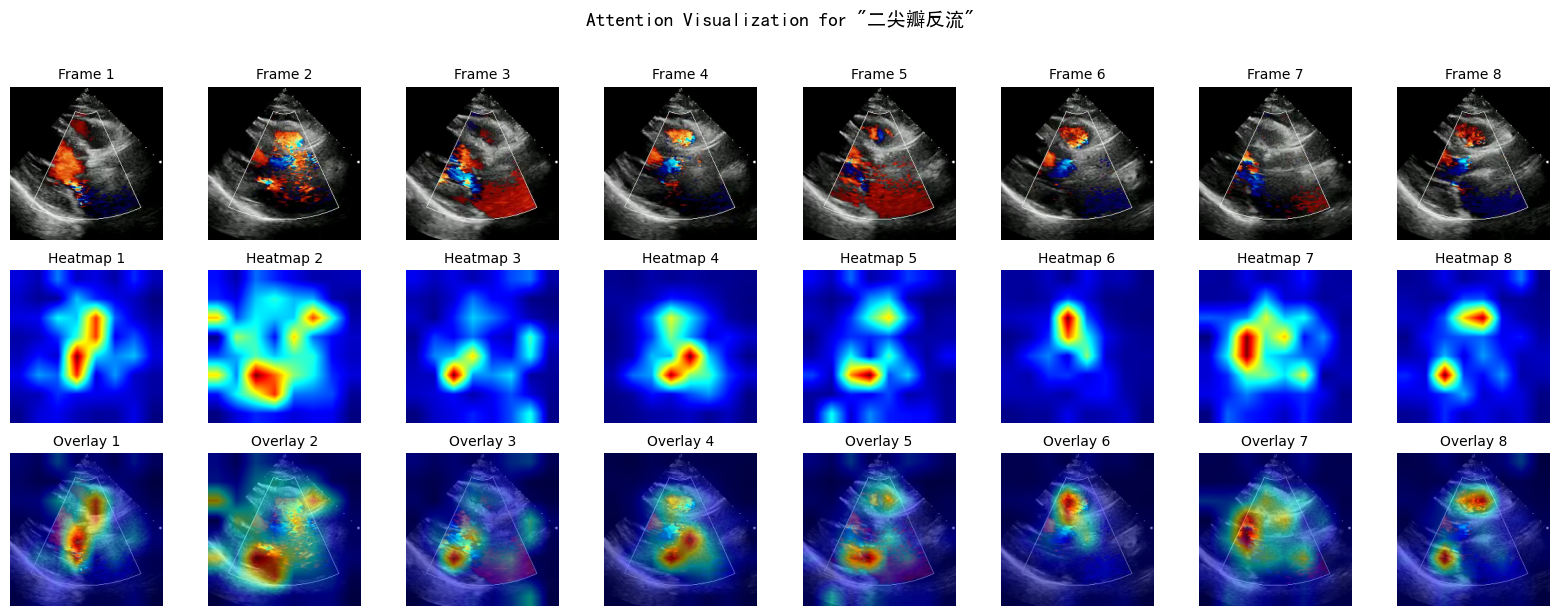

In [14]:
###  2.   有视频
msg=   {
    "id": "Dataset/group_5/2024040121443100050569525e9",
    "video": [
      "../../Data/dicom_videos_group/Dataset/group_5/2024040121443100050569525e9/Doppler_Parasternal_Long.mp4"
    ],
    "diag_item": "二尖瓣反流",
    "mark": 1,
    "conversations": [
      {
        "from": "human",
        "value": "<video>\n请分析这段心脏超声视频，请根据超声影像特征判断是否存在二尖瓣反流现象。只输出'是'或'否'"
      },
      {
        "from": "gpt",
        "value": "是"
      }
    ]
  }
msg["conversations"][0]["value"] = "<video>\n请查看这段超声视频，并仔细观察二尖瓣的位置是否有二尖瓣反流的特征，如果有，描述其严重程度。"
root=""
msg["video"][0]=os.path.join(root,msg["video"][0])
video_url = msg["video"][0]
prompt = msg["conversations"][0]["value"].replace("<video>","").strip()
video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
print(len(frames))
image_grid = create_image_grid(frames, num_columns=8)
# display(image_grid.resize((640, 640)))
# 
print("视频路径:", video_path)
model.to("cuda:0")
result = inference(model,processor,video_path, prompt)
print(result["response_msg"])
extract_attentions(msg,result,processor,save_path=None,vis=False)

64
视频路径: ../../Data/dicom_videos_group/Dataset/group_5/2024041804351700050569525e9/Doppler_Parasternal_Long.mp4
是

在心室收缩期时可见到血流从左房向右室逆着流动的现象称为二尖瓣反流（mitral regurgitation）。 在这个过程中可以看到心脏内部有明显的血液倒流现象，在且这种现象通常发生在心脏泵送功能不佳的情况下。

根据您提供的图片信息，“V”字型结构代表了患者的心脏部位，其中“O”部分显示的是患者的肺部区域。“o”则表示的是心脏的具体位置。通过这些标记我们可以看到心脏内存在大量的红色箭头符号，这表明在这个阶段有大量的血液正在流向右侧的心腔中去。因此可以判断出该病人确实出现了严重的二尖瓣反流症状。


输出token序列:
0 是 1 

 2 在 3 心 4 室 5 收缩 6 期 7 时 8 可见 9 到 10 血 11 流 12 从 13 左 14 房 15 向 16 右 17 室 18 逆 19 着 20 流动 21 的现象 22 称为 23 二 24 尖 25 瓣 26 反 27 流 28 （ 29 mit 30 ral 31  reg 32 urg 33 itation 34 ）。 35  在 36 这个 37 过程中 38 可以看到 39 心脏 40 内部 41 有 42 明显的 43 血液 44 倒 45 流 46 现象 47 ，在 48 且 49 这种 50 现象 51 通常 52 发生在 53 心脏 54 泵 55 送 56 功能 57 不佳 58 的情况下 59 。

 60 根据 61 您 62 提供的 63 图片 64 信息 65 ，“ 66 V 67 ” 68 字 69 型 70 结构 71 代表 72 了 73 患者 74 的心 75 脏 76 部位 77 ， 78 其中 79 “ 80 O 81 ” 82 部分 83 显示 84 的是 85 患者的 86 肺 87 部 88 区域 89 。“ 90 o 91 ” 92 则 93 表示 94 的是 95 心脏 96 的具体 97 位置 98 。 99 通过 100 这些 101 标记 102 我们可以 103 看到 104 心脏 105 内 106 存在 107 大

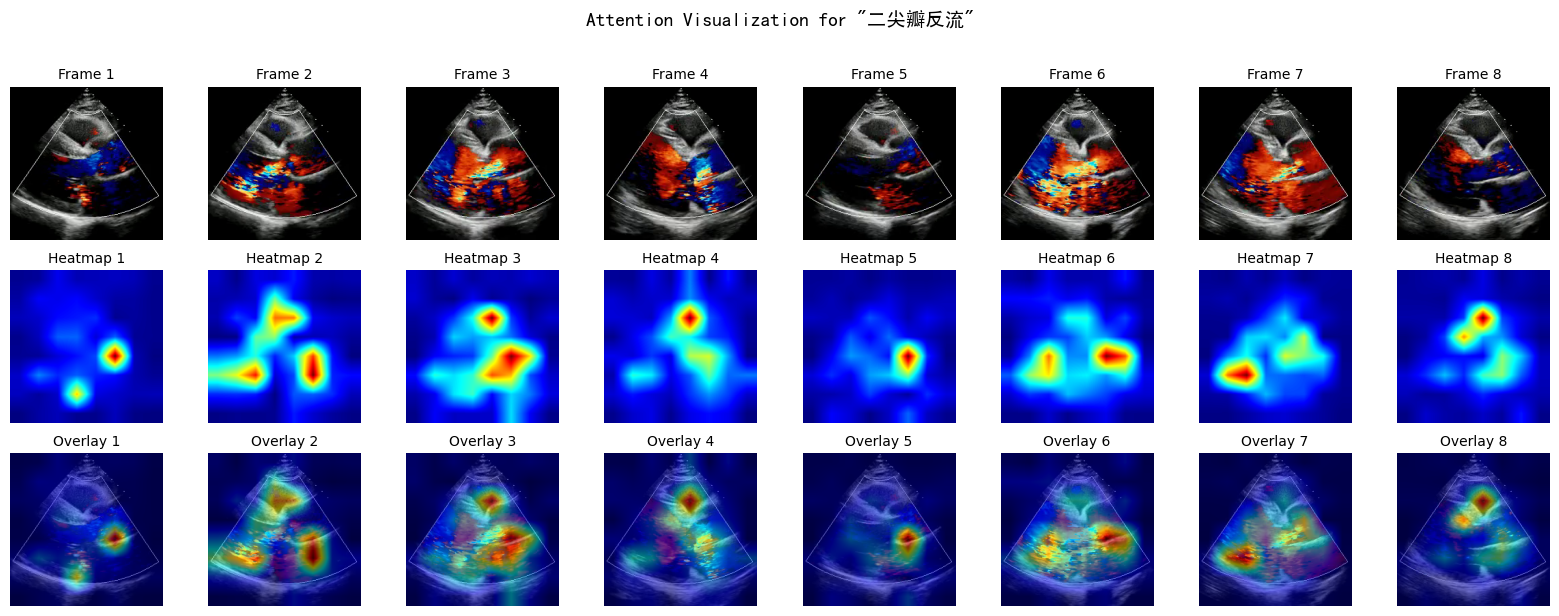

In [15]:
###  2.   有视频
msg= {
    "id": "Dataset/group_5/2024041804351700050569525e9",
    "video": [
      "../../Data/dicom_videos_group/Dataset/group_5/2024041804351700050569525e9/Doppler_Parasternal_Long.mp4"
    ],
    "diag_item": "二尖瓣反流",
    "mark": 1,
    "conversations": [
      {
        "from": "human",
        "value": "<video>\n请分析这段心脏超声视频，请根据超声影像特征判断是否存在二尖瓣反流现象。只输出'是'或'否'"
      },
      {
        "from": "gpt",
        "value": "是"
      }
    ]
  }
msg["conversations"][0]["value"] = "<video>\n请查看这段超声视频，并仔细观察二尖瓣的位置是否有二尖瓣反流的特征，如果有，描述其严重程度。"
root=""
msg["video"][0]=os.path.join(root,msg["video"][0])
video_url = msg["video"][0]
prompt = msg["conversations"][0]["value"].replace("<video>","").strip()
video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
print(len(frames))
image_grid = create_image_grid(frames, num_columns=8)
# display(image_grid.resize((640, 640)))
# 
print("视频路径:", video_path)
model.to("cuda:0")
result = inference(model,processor,video_path, prompt)
print(result["response_msg"])
extract_attentions(msg,result,processor,save_path=None,vis=False)

64
视频路径: ../../Data/dicom_videos_group/Dataset/group_5/2024032814245900050569525e9/Doppler_Parasternal_Long.mp4
是图片所示，患者存在二尖瓣狭窄和关闭不全的情况，在此情况下可见左心房增大、肺动脉高压及右室肥厚等表现；在心脏彩超中显示：1）二维图像上见双侧房室口增宽伴收缩期前移（提示为腱索断裂），2)彩色多普勒血流显像示主动脉根部扩张并有大量返流信号(重度)，3)CDFI: 双向房室口均可见少量舒张早期反流束，考虑轻度-中度反流

输出token序列:
0 是 1 图片 2 所示 3 ， 4 患者 5 存在 6 二 7 尖 8 瓣 9 狭窄 10 和 11 关闭 12 不 13 全 14 的情况 15 ，在 16 此 17 情况下 18 可见 19 左 20 心 21 房 22 增大 23 、 24 肺 25 动脉 26 高压 27 及 28 右 29 室 30 肥 31 厚 32 等 33 表现 34 ； 35 在 36 心脏 37 彩 38 超 39 中 40 显示 41 ： 42 1 43 ） 44 二维 45 图像 46 上 47 见 48 双 49 侧 50 房 51 室 52 口 53 增 54 宽 55 伴 56 收缩 57 期 58 前 59 移 60 （ 61 提示 62 为 63 腱 64 索 65 断裂 66 ）， 67 2 68 ) 69 彩色 70 多 71 普 72 勒 73 血 74 流 75 显 76 像 77 示 78 主动 79 脉 80 根 81 部 82 扩张 83 并 84 有 85 大量 86 返 87 流 88 信号 89 ( 90 重度 91 )， 92 3 93 ) 94 CDF 95 I 96 : 97  � 98 � 99 向 100 房 101 室 102 口 103 均 104 可见 105 少量 106 舒 107 张 108 早期 109 反 110 流 111 束 112 ， 113 考虑 114 轻 115 度 116 - 117 中 118 度 119 反 120 流 121 <|im_end|> 

注意力提取区间: 15 527
输入的词索引: 117 121


检查关键词: 中度反流


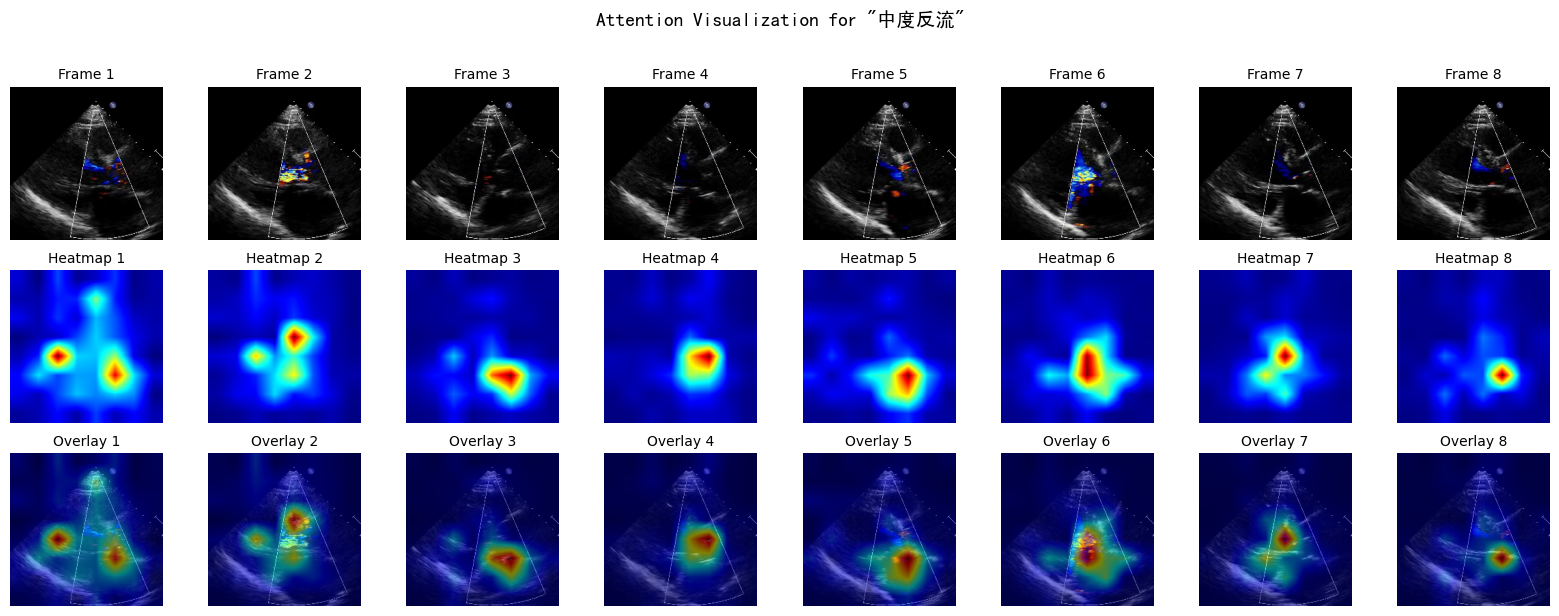

In [16]:
###  2.   有视频
msg= {
    "id": "Dataset/group_5/2024032814245900050569525e9",
    "video": [
      "../../Data/dicom_videos_group/Dataset/group_5/2024032814245900050569525e9/Doppler_Parasternal_Long.mp4"
    ],
    "diag_item": "二尖瓣反流",
    "mark": 1,
    "conversations": [
      {
        "from": "human",
        "value": "<video>\n请分析这段心脏超声视频，请根据超声影像特征判断是否存在二尖瓣反流现象。只输出'是'或'否'"
      },
      {
        "from": "gpt",
        "value": "是"
      }
    ]
  }
msg["conversations"][0]["value"] = "<video>\n请查看这段超声视频，并仔细观察二尖瓣的位置是否有二尖瓣反流的特征，如果有，描述其严重程度。"
root=""
msg["video"][0]=os.path.join(root,msg["video"][0])
video_url = msg["video"][0]
prompt = msg["conversations"][0]["value"].replace("<video>","").strip()
video_path, frames, timestamps = get_video_frames(video_url, num_frames=64)
print(len(frames))
image_grid = create_image_grid(frames, num_columns=8)
# display(image_grid.resize((640, 640)))
# 
print("视频路径:", video_path)
model.to("cuda:0")
result = inference(model,processor,video_path, prompt)
print(result["response_msg"])
extract_attentions(msg,result,processor,save_path=None,vis=False)